In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import os
from joblib import dump, load
from collections import Counter

# Métricas e ferramentas de Machine Learning
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder
from sklearn import preprocessing
from scipy.spatial.distance import cdist
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
 
dados = pd.read_csv ("../Databases/base_treino_boruta.csv", sep=',')
dados

,sample_id,MIMAT0000070,MIMAT0000103,MIMAT0003240,MIMAT0004592,MIMAT0004602,MIMAT0004804,MIMAT0005586,MIMAT0007347,MIMAT0016849,...,MIMAT0027478,MIMAT0027498,MIMAT0027540,MIMAT0027574,MIMAT0027575,MIMAT0027660,MIMAT0027686,MIMAT0031000,target,split
0,GSM2278615,1.030720,1.152392,-0.321811,-0.388305,-0.632559,-0.006389,-0.173028,0.734924,-0.538253,...,0.558312,0.682544,-0.281433,-0.152731,-0.136623,0.091852,-0.503763,1.053621,1,train
1,GSM2278616,1.773204,0.953377,-0.173949,-0.473914,-0.558560,0.032618,0.436156,0.842601,-0.515910,...,2.327494,0.270474,-1.432550,0.126085,1.908569,-0.476252,-0.810687,0.903694,1,train
2,GSM2278617,0.684740,0.403192,-0.496596,-0.608497,-0.066235,-1.190762,2.336523,0.121293,-0.042676,...,0.379008,0.212516,-0.912393,2.028289,-0.133262,-1.409829,-0.114039,0.013329,1,train
3,GSM2278618,-0.794088,-1.039456,-0.325646,-0.392525,-0.382181,-0.085807,0.056988,1.684487,-0.236236,...,1.159776,-0.186710,-1.223107,0.149769,-0.128983,-1.642710,0.321930,0.527365,1,train
4,GSM2278619,-1.453257,-0.910481,-0.491062,-0.424341,-0.479572,-0.036304,0.178505,0.631550,-0.728127,...,-0.839302,-0.348432,-0.809020,0.294022,0.486672,-1.282433,-1.035871,0.367641,1,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,GSM1447837,1.328089,0.849867,1.410876,2.054690,1.477953,1.944974,-0.440131,-0.042935,-0.007901,...,-0.860789,-0.101230,0.246102,-0.030673,-1.283171,1.365195,0.346937,-0.132385,0,train
281,GSM1447839,-1.429717,-1.267393,1.671507,2.089174,1.935565,-0.035735,0.167215,-0.624830,0.249774,...,-1.316962,1.582785,1.226486,-3.219079,-1.514643,2.006021,1.122274,-2.233914,0,train
282,GSM1447840,-0.345422,-0.366692,1.147987,1.722085,1.612545,0.596328,-0.269979,-1.103681,0.572284,...,-0.574166,-0.939608,2.324517,-1.450733,-0.072031,0.567534,1.845342,-0.367161,0,train
283,GSM1447841,-0.365179,-1.267393,0.078382,1.693163,1.418407,0.877449,-1.697361,-0.624830,0.445940,...,0.511769,-0.565786,0.997730,-1.529889,0.126708,0.120642,1.411211,1.093030,0,train


In [2]:
# normalizar
# remover colunas que não são features
dados_num = dados.drop(columns=["sample_id", "target", "split"])

# target (0/1) separado como categorico
dados_cat = dados[["target"]]

# Instanciar o objeto normalizador
normalizador = preprocessing.MinMaxScaler()

# treinar o normalizador apenas nas features
modelo_normalizador_num = normalizador.fit(dados_num)

# salvando modelo normalizador
dump(modelo_normalizador_num, open("models_Tree/normalizador_TCC.model","wb"))

# normalizar atributos numéricos
dados_num_normalizado = modelo_normalizador_num.transform(dados_num)

# converter de volta para DataFrame
dados_num_df = pd.DataFrame(dados_num_normalizado, columns=dados_num.columns)

# juntar target (0/1) e split
dados_final = dados_num_df.join(dados_cat).join(dados[["split"]])
dados_final

,MIMAT0000070,MIMAT0000103,MIMAT0003240,MIMAT0004592,MIMAT0004602,MIMAT0004804,MIMAT0005586,MIMAT0007347,MIMAT0016849,MIMAT0018192,...,MIMAT0027478,MIMAT0027498,MIMAT0027540,MIMAT0027574,MIMAT0027575,MIMAT0027660,MIMAT0027686,MIMAT0031000,target,split
0,0.642643,0.556037,0.507214,0.198630,0.352515,0.568801,0.397176,0.449194,0.413662,0.444543,...,0.624663,0.630741,0.442053,0.527822,0.615689,0.483571,0.342527,0.473657,1,train
1,0.773114,0.515801,0.533194,0.175908,0.368558,0.574554,0.508098,0.465468,0.418135,0.570501,...,0.934508,0.569896,0.242716,0.575816,0.936687,0.406730,0.288510,0.452056,1,train
2,0.581846,0.404566,0.476502,0.140186,0.475293,0.394103,0.854120,0.356452,0.512861,0.398060,...,0.593260,0.561338,0.332790,0.903250,0.616216,0.280456,0.411117,0.323775,1,train
3,0.321981,0.112897,0.506540,0.197510,0.406797,0.557086,0.439058,0.592709,0.474116,0.511615,...,0.730000,0.502390,0.278985,0.579893,0.616888,0.248957,0.487846,0.397836,1,train
4,0.206149,0.138973,0.477475,0.189066,0.385683,0.564388,0.461184,0.433571,0.375656,0.608076,...,0.379892,0.478510,0.350691,0.604724,0.713517,0.297687,0.248878,0.374823,1,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,0.694897,0.494874,0.811663,0.847058,0.810070,0.856631,0.348542,0.331630,0.519822,0.579420,...,0.376128,0.515011,0.533405,0.548833,0.435735,0.655801,0.492248,0.302781,0,train
281,0.210286,0.066814,0.857459,0.856211,0.909279,0.564472,0.459128,0.243684,0.571400,0.609914,...,0.296237,0.763669,0.703176,0.000000,0.399405,0.742478,0.628704,0.000000,0,train
282,0.400822,0.248914,0.765471,0.758777,0.839249,0.657703,0.379523,0.171312,0.635956,0.782556,...,0.426326,0.391219,0.893320,0.304392,0.625827,0.547911,0.755962,0.268956,0,train
283,0.397350,0.066814,0.577531,0.751101,0.797160,0.699169,0.119623,0.243684,0.610666,1.000000,...,0.616511,0.446416,0.663563,0.290767,0.657019,0.487465,0.679556,0.479335,0,train


In [3]:
# separar target e atributos
dados_classes = dados_final[['target']]
dados_atributos = dados_final.drop(columns=['target', 'split'])

# preencher NaNs numericos com media (so um seguro)
dados_atributos = dados_atributos.fillna(dados_atributos.mean())

# converter target para array binario (0/1)
dados_classes_bin = dados_classes['target'].values

resampler = SMOTE(random_state=42)

dados_atributos_b, dados_classes_b = resampler.fit_resample(dados_atributos,dados_classes_bin)

# frequência apos balanceamento
print('------ FREQUÊNCIA DAS CLASSES APÓS O BALANCEAMENTO ------')
print(Counter(dados_classes_b))

c:\Users\cassi\miniconda3\envs\cancer_gpu\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------ FREQUÊNCIA DAS CLASSES APÓS O BALANCEAMENTO ------
Counter({np.int64(1): 150, np.int64(0): 150})


In [4]:
# Treinar RandomForest e calcular permutation importance
print("\nTreinamento com RandomForest")

rf = RandomForestClassifier(
    n_estimators=2000,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(dados_atributos_b, dados_classes_b)

# salvar
os.makedirs('models_Tree', exist_ok=True)

caminho_rf = os.path.join(os.getcwd(),'models_Tree','modelo_RF.joblib')

dump(rf, caminho_rf)

print(f"RF salvo em: {caminho_rf}")

# feature importances
imp = rf.feature_importances_

cols = pd.Index(dados_atributos.columns)

imp_df = pd.DataFrame({'feature': cols,'impurity_imp': imp}).sort_values('impurity_imp',ascending=False)

# carregar base de teste
dados_teste = pd.read_csv("../Databases/base_teste_boruta.csv")

X_test = dados_teste.drop(columns=["sample_id", "target", "split"])
y_test = dados_teste["target"]

# aplicar o mesmo tratamento usado no treino
X_test = X_test.fillna(X_test.mean())

# carregar normalizador salvo
modelo_normalizador_num = load("models_Tree/normalizador_TCC.model")

X_test = modelo_normalizador_num.transform(X_test)
X_test = pd.DataFrame(X_test,columns=cols)

# permutation importance
print('Calculando permutation importance (pode demorar) ...')

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_means = pd.Series(perm.importances_mean,index=cols)

perm_df = perm_means.sort_values(ascending=False).rename('perm_mean')

print('\nTop 20 (impurity)')
print(imp_df.head(20))

print('\nTop 20 (permutation)')
print(perm_df.head(20))

print('\nRandomForest training + permutation importance completo.')


Treinamento com RandomForest
RF salvo em: c:\Users\cassi\OneDrive\Documentos\1-Programas\TCC\RandonForest - CPU\models_Tree\modelo_RF.joblib
Calculando permutation importance (pode demorar) ...

Top 20 (impurity)
         feature  impurity_imp
4   MIMAT0004602      0.156395
3   MIMAT0004592      0.096250
20  MIMAT0023700      0.090734
31  MIMAT0027686      0.080070
8   MIMAT0016849      0.063356
18  MIMAT0022693      0.049469
2   MIMAT0003240      0.046283
13  MIMAT0019003      0.039305
29  MIMAT0027575      0.028399
16  MIMAT0019964      0.027591
24  MIMAT0027431      0.023398
5   MIMAT0004804      0.023290
11  MIMAT0018971      0.022638
23  MIMAT0027359      0.021879
26  MIMAT0027498      0.019786
27  MIMAT0027540      0.018597
14  MIMAT0019020      0.018401
7   MIMAT0007347      0.017980
22  MIMAT0026720      0.016702
32  MIMAT0031000      0.014244

Top 20 (permutation)
MIMAT0000103    0.009722
MIMAT0027574    0.009722
MIMAT0027498    0.008333
MIMAT0027478    0.006944
MIMAT0027686 

Accuracy : 0.9444444444444444
Precision: 0.9047619047619048
Recall   : 1.0
F1 Score : 0.95
ROC AUC  : 0.9910990712074303

               precision    recall  f1-score   support

           0       1.00      0.88      0.94        34
           1       0.90      1.00      0.95        38

    accuracy                           0.94        72
   macro avg       0.95      0.94      0.94        72
weighted avg       0.95      0.94      0.94        72


Análise de Importância das Features na Random Forest
Figura salva: plots\MDI_Top15.png


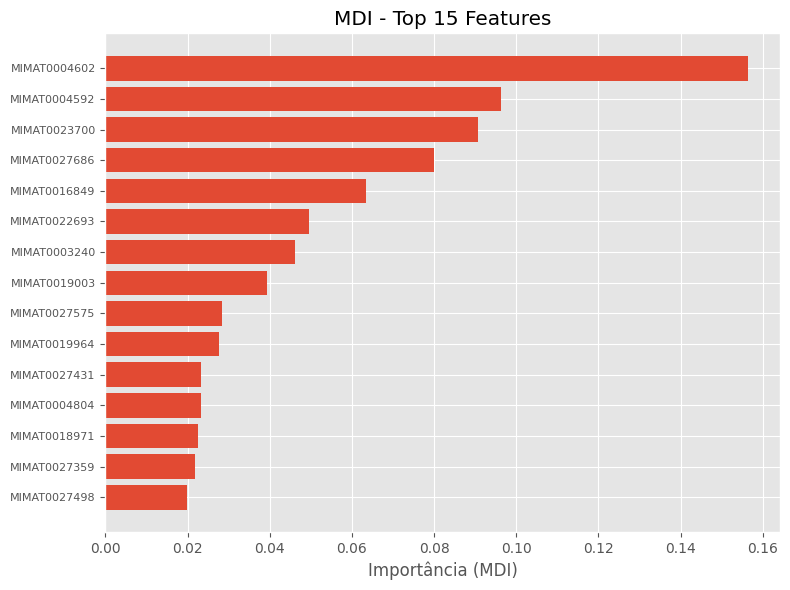

Figura salva: plots\Permutacao_Top15.png


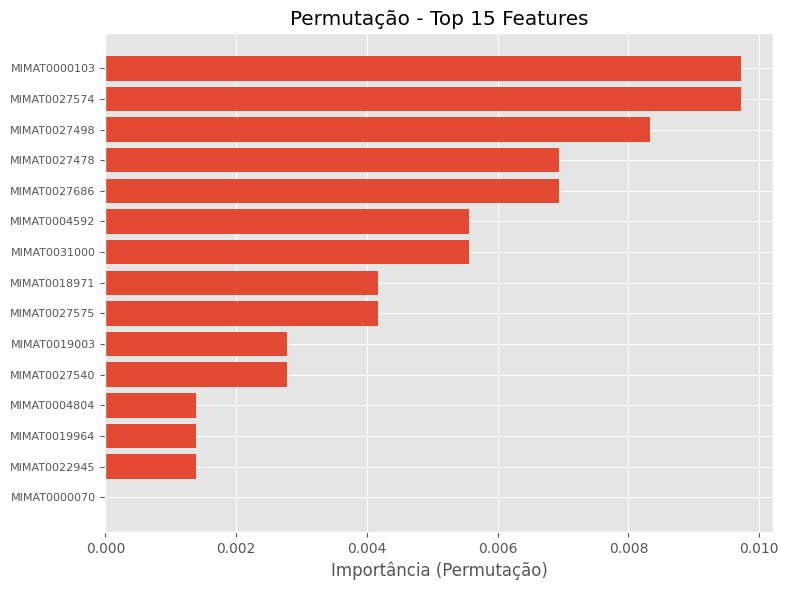


Correlação entre MDI e Permutação: -0.3562


In [ ]:
# CARREGAR BASE DE TESTE
dados_teste = pd.read_csv("../Databases/base_teste_boruta.csv")

X_test = dados_teste.drop(columns=["sample_id", "target", "split"])
y_test = dados_teste["target"]

# CARREGAR NORMALIZADOR
normalizador = load(open("models_Tree/normalizador_TCC.model", "rb"))

X_test = normalizador.transform(X_test)

X_test = pd.DataFrame(
    X_test,
    columns=dados_atributos.columns
)


# PREDIÇÃO
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]


# MÉTRICAS
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\n", classification_report(y_test, y_pred))


# FEATURE IMPORTANCE
print("\nAnálise de Importância das Features na Random Forest")

plt.style.use('ggplot')
os.makedirs('plots', exist_ok=True)

top_k = 15
features = dados_atributos.columns

imp_df = pd.DataFrame({
    'Feature': features,
    'Importância (MDI)': imp,
    'Importância (Permutação)': perm.importances_mean
})

k = min(top_k, len(imp_df))

# GRÁFICO MDI
top_mdi = imp_df.nlargest(k, 'Importância (MDI)').iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_mdi['Feature'], top_mdi['Importância (MDI)'])
ax.set_title(f'MDI - Top {k} Features')
ax.set_xlabel('Importância (MDI)')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()

out_mdi = os.path.join('plots', f'MDI_Top{k}.png')
fig.savefig(out_mdi, dpi=300, bbox_inches='tight')

print(f'Figura salva: {out_mdi}')

plt.show()
plt.close(fig)

# GRÁFICO PERMUTAÇÃO
top_perm = imp_df.nlargest(k, 'Importância (Permutação)').iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_perm['Feature'], top_perm['Importância (Permutação)'])
ax.set_title(f'Permutação - Top {k} Features')
ax.set_xlabel('Importância (Permutação)')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()

out_perm = os.path.join('plots', f'Permutacao_Top{k}.png')
fig.savefig(out_perm, dpi=300, bbox_inches='tight')

print(f'Figura salva: {out_perm}')

plt.show()
plt.close(fig)

# CORRELAÇÃO ENTRE MÉTRICAS
try:
    corr = np.corrcoef(
        imp,
        perm.importances_mean
    )[0, 1]
except Exception:
    corr = float('nan')

print(f"\nCorrelação entre MDI e Permutação: {corr:.4f}")

In [6]:
# CARREGAR NORMALIZADOR
normalizador = load(open("models_Tree/normalizador_TCC.model", "rb"))

# CARREGAR MODELO TREINADO
modelo = load("models_Tree/modelo_RF.joblib")

print("Modelo carregado com sucesso!")

# CARREGAR BASE DE TESTE
dados_teste = pd.read_csv("../Databases/base_teste_boruta.csv")

# SELECIONAR PACIENTE ALEATÓRIO
paciente = dados_teste.sample(1, random_state=random.randint(1,10000))

sample_id = paciente["sample_id"].iloc[0]
classe_real = paciente["target"].iloc[0]

# REMOVER COLUNAS QUE NÃO ENTRAM NO MODELO
paciente_df = paciente.drop(columns=["sample_id", "target", "split"])

# NORMALIZAR
paciente_norm = normalizador.transform(paciente_df)

paciente_norm_df = pd.DataFrame(
    paciente_norm,
    columns=paciente_df.columns
)

# INFERÊNCIA
def fazer_inferencia(paciente_df):

    print("\nRealizando inferência...\n")

    proba = modelo.predict_proba(paciente_df)[0][1]

    pred = modelo.predict(paciente_df)[0]

    print(f"Sample ID           : {sample_id}")
    print(f"Classe real         : {classe_real}")
    print(f"Classe prevista     : {pred}")
    print(f"Probabilidade PDAC  : {proba:.4f}")

    return pred, proba


classe_predita, probabilidade = fazer_inferencia(paciente_norm_df)

# RESULTADO
df_prob = pd.DataFrame({
    "Sample_ID": [sample_id],
    "Classe Real": [classe_real],
    "Classe Prevista": [classe_predita],
    "Probabilidade PDAC (%)": [probabilidade * 100]
})

print("\nResultado final:")
print(df_prob)

Modelo carregado com sucesso!

Realizando inferência...

Sample ID           : GSM2278644
Classe real         : 1
Classe prevista     : 1
Probabilidade PDAC  : 0.8090

Resultado final:
    Sample_ID  Classe Real  Classe Prevista  Probabilidade PDAC (%)
0  GSM2278644            1                1                    80.9
